In [18]:
# Standard library
import json
from copy import copy
from math import ceil, isfinite
from pathlib import Path
from time import monotonic
from typing import Any
from itertools import compress

# Math
import numpy as np
from numpy import array, deg2rad, eye, mean, ndarray, pi, set_printoptions, stack, rad2deg, deg2rad
from numpy.random import seed, standard_normal
from scipy.stats import norm, uniform

# Data Handling
import utm
import pandas as pd
from filterpy.monte_carlo import systematic_resample, stratified_resample

# Other Third Party
from rich.progress import track

# Plotting
import matplotlib
from keplergl import KeplerGl
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.transforms import Affine2D
from seaborn import move_legend
from svgpath2mpl import parse_path
from svgpathtools import svg2paths
import seaborn as sns

# ProMis
from promis import ProMis, DeltaStaRMap
from promis.geo import (
    CartesianCollection,
    DeltaGrid,
    CartesianDeltaCollection,
    CartesianLocation,
    CartesianMap,
    CartesianRasterBand,
    PolarCollection,
    PolarLocation,
    BufferedPolarPolygon,
    BufferedPolygon,
)
from promis.geo.helpers import calculate_street_width
from promis.loaders import OsmLoader
from promis.logic.spatial import Depth


In [19]:
# This will auto-relead changed ProMis imports
%reload_ext autoreload
%autoreload 2

# The inD Dataset
https://levelxdata.com/ind-dataset/

https://levelxdata.com/wp-content/uploads/2024/03/inD-Format_1_1.pdf

- verschieben der Karte entsprechend der Umgebung
- anpassen der Weite
- für jede situation, (groupby frame?) berechne eine landscape, in der alle agenten verzeichnet sind.
- wir selbst stehen in der Mitte. Unser Heading / speed ist lowkey egal dafür? vielleicht auch hierzu nochmal mit / ohne experimente machen.

In [20]:
data_path = Path(".") / "data" / "inD-dataset-v1.1" / "data"
inD_index = "08"

# setting = f"inD-crossing-{inD_index}"
output_folder = Path(".") / "ground-cofi-exports" / "all"
output_folder.mkdir(exist_ok=True, parents=True)

uam_path = output_folder / "uam"
star_path = output_folder / "star"
promis_path = output_folder / "promis"

for path in [uam_path, star_path, promis_path]:
    path.mkdir(exist_ok=True)


In [21]:
def load_inD_data(inD_index: str):
    metadata = pd.read_csv(data_path / f"{inD_index}_recordingMeta.csv", sep=',')
    car_data = pd.read_csv(data_path / f"{inD_index}_tracks.csv", sep=',')
    car_metadata = pd.read_csv(data_path / f"{inD_index}_tracksMeta.csv", sep=',')
    assert metadata["recordingId"].unique() == car_data["recordingId"].unique() == car_metadata["recordingId"].unique()

    # naive center of the scene, but not our origin of coordinates
    # we use this as a bootstrap
    origin = PolarLocation(
        latitude=metadata["latLocation"][0], longitude=metadata["lonLocation"][0]
    )

    # the dataset uses a local coordinate frame based on the UTM projection.
    # the local frame resembles a CartesianCollection, we just need to transform its origin point
    utm_number = utm.latlon_to_zone_number(origin.latitude, origin.longitude)
    utm_letter = utm.latitude_to_zone_letter(origin.latitude)

    origin_coords = utm.to_latlon(
        easting=metadata["xUtmOrigin"][0],
        northing=metadata["yUtmOrigin"][0],
        zone_number=utm_number,
        zone_letter=utm_letter,
    )
    origin = PolarLocation(longitude=origin_coords[1], latitude=origin_coords[0])

    x_utm = car_data["xCenter"] + metadata["xUtmOrigin"][0]
    y_utm = car_data["yCenter"] + metadata["yUtmOrigin"][0]
    polar_car_coords = np.array(
        [utm.to_latlon(x, y, utm_number, utm_letter) for x,y in zip(x_utm, y_utm)]
    )[:, ::-1] # polar coordinates are parsed longitude first, but the conversion returns coordinates in reverse order
    polar_car_coord_collection = PolarCollection(origin)
    polar_car_coord_collection.append_with_default(polar_car_coords, 0)
    cartesian_car_cords = polar_car_coord_collection.to_cartesian().coordinates()

    car_data["xCenter_utm"] = car_data["xCenter"]
    car_data["yCenter_utm"] = car_data["yCenter"]
    car_data["xCenter"] = cartesian_car_cords[:, 0] 
    car_data["yCenter"] = cartesian_car_cords[:, 1] 

    # we now want to translate the origin to the approximate center of the scene
    # that way, we avoid to compute lots of uninteresting points
    bounds = [[car_data[row].max(), car_data[row].min()] for row in ["xCenter", "yCenter"]]
    offsets = [mean(bound_pair) for bound_pair in bounds]
    diameter = np.ceil( max([bound_pair[0] - bound_pair[1] for bound_pair in bounds]) / 10) * 10

    origin = CartesianLocation(*offsets).to_polar(origin)
    dimensions = width, height = diameter, diameter

    collection = CartesianDeltaCollection(origin=origin, number_of_values=0)
    car_data["xCenter"] = car_data["xCenter"] - offsets[0]
    car_data["yCenter"] = car_data["yCenter"] - offsets[1]
    car_data["speed"] = np.sqrt(np.pow(car_data["xVelocity"], 2) + np.pow(car_data["yVelocity"], 2)) * 3.6
    car_data = car_data.join(car_metadata[["trackId", "class"]], on="trackId", how="left", rsuffix="r", validate="m:1")
    del car_data["trackIdr"]

    collection.append_with_default(car_data[["xCenter", "yCenter", "heading", "speed"]].values, value=())
    dt = 1 / metadata["frameRate"]
    

    return car_data, collection, origin, dimensions, dt

In [ ]:
feature_description = {
    "primary": "['highway' = 'primary']",
    "secondary": "['highway' = 'secondary']",
    "tertiary": "['highway' = 'tertiary']",
    "service": "['highway' = 'service']",
    "residential": "['highway' = 'residential']",
    "crossing": "['footway' = 'crossing']",
    "living_street": "[highway=living_street]",
    "unclassified": "['highway' = 'unclassified']",
    "signal": "['highway' = 'traffic_signals']",
    "stop_sign": "['highway' = 'stop']",
}

covariance = {
    "primary": 2 * np.eye(2),
    "secondary": 3 * np.eye(2),
    "tertiary": 3 * np.eye(2),
    "residential": 3 * np.eye(2),
    "living_street": 3 * np.eye(2),
    "service": 4 * np.eye(2),
    "unclassified": 3 * np.eye(2),
}

covariance |= {
    f"left_{key}": covariance[key]
    for key in covariance.keys()
} | {
    f"right_{key}": covariance[key]
    for key in covariance.keys()
}
covariance |= {
    "intersection": 2 * np.eye(2),
    "crossing": 2 * np.eye(2),
    "signal": 2*np.eye(2),

}

general_logic = """
    correct(X, primary) :-
        over(X, primary).

    correct(X, Location) :-
        over(X, Location),
        state_speed(X, S),
        maxspeed(X, Location, MS),
        MS >= S.

    % Definition of a valid mission
    landscape(X) :-
        correct(X, primary);
        correct(X, secondary);
        correct(X, tertiary);
        % and so on...
        correct(X, unclassified).
"""

In [23]:
intersection_logic = """
    unclassified_correct(X) :-
        over(X, unclassified),
        state_speed(X, S),
        maxspeed(X, unclassified, MS),
        MS >= S.

    tertiary_correct(X) :-
        over(X, tertiary),
        state_speed(X, S),
        maxspeed(X, tertiary, MS),
        MS >= S.

    % Definition of a valid mission
    landscape(X) :-
        tertiary_correct(X);
        unclassified_correct(X);
        distance(X, intersection) < 10.
"""

In [24]:
road_types = [
    "secondary",
    "tertiary",
    "residential",
    "unclassified",
]

def angle_logic_prob(intersection_prob = "0.5") -> str:
    return f"""
        bearing(X) ~ normal(B, 0.001) :- state_bearing(X, B).    

        along(X, LocationType) :- 
        angle(X, LocationType) + bearing(X)   <  90.0,
        angle(X, LocationType) + bearing(X)   > -90.0.

        on_correct_side(X, LocationType) :- 
            along(X, LocationType),
            over(X, right, LocationType);
            not along(X, LocationType),
            over(X, left, LocationType).

        % Definition of a valid mission
        side_correct(X) :-
            on_correct_side(X, secondary);
            on_correct_side(X, tertiary);
            on_correct_side(X, residential);
            on_correct_side(X, unclassified).

        landscape(X) :- distance(X, intersection) >= 10, side_correct(X).
        
        {intersection_prob}::landscape(X) :- distance(X, intersection) < 10.
        
    """ + \
    "\n".join([f"""over(X, right, {key}) :- over(X, right_{key}). 
    over(X, left, {key}) :- over(X, left_{key}).""" for key in road_types])

angle_logic = angle_logic_prob("0.5")
angle_logic_full = angle_logic_prob("1.0")

angle_logic_requirements = "\n".join([
f"""over(X, left_{key})
over(X, right_{key})
angle(X, {key})
""" for key in road_types
]) + """
distance(X, intersection)
"""

In [25]:
# intersections are unmarked in OSM. As per the wiki, Intersections are represented using shared nodes.
# we therefore use a preprocessor that checks every node with every other node to see wether they are close
def fetch_intersections(
        uam: CartesianMap, 
        number_of_arms = 3, 
        intersection_location_type="intersection", 
        delta = 0.01,
    ) -> list[CartesianLocation]:

    intersection_points: list[CartesianLocation] = []
    for feature_index, feature in enumerate(uam.features):
        if not isinstance(feature, BufferedPolygon): # only buffered ways could be roads that intersect
            continue
        feature_locs = feature.polyline.to_polar().to_cartesian(uam.origin).to_numpy()
        num_close_points = np.zeros(feature_locs.shape[0])
        

        for other_feature_index, other_feature in enumerate(uam.features[feature_index+1:]):
            if not isinstance(other_feature, BufferedPolygon): # only buffered ways could be roads that intersect
                continue
            other_locs = other_feature.polyline.to_polar().to_cartesian(uam.origin).to_numpy()
            feature_mat = np.atleast_3d(feature_locs).repeat(other_locs.shape[0], axis=2)
            other_mat = np.atleast_3d(other_locs).repeat(feature_locs.shape[0], axis=2).transpose((2, 1, 0))
            # mat axes: 0-len(features); 1-2; 2-len(other_features)

            dists = np.sqrt(np.pow(feature_mat-other_mat, 2).sum(axis=1))
            num_close_points += np.sum(dists < delta, axis=1)
            
        new_points = compress(feature.polyline.locations, num_close_points >= number_of_arms - 1)
        intersection_points.extend(
            [new_point for new_point in new_points 
            if not any([new_point.distance(old_point) < delta for old_point in intersection_points])]
        )
    return [CartesianLocation(east=loc.east,
        north=loc.north,
        location_type=intersection_location_type,
        name=loc.name,
        origin=uam.origin,
    ) for loc in intersection_points]

In [36]:
def build_uam(origin, dimensions, inD_index:str, covariance):
    uam = OsmLoader(
        origin=origin,
        dimensions=dimensions,
        feature_description=feature_description,
        polygonize_routes=True,
        timeout=30,
    ).to_cartesian_map()
    uam.features.extend(fetch_intersections(uam))
    uam.apply_covariance(covariance)
    
    uam.save(uam_path / f"uam-{inD_index}.pkl")


In [37]:
def plot_traj_shift(cars):
    fig, ax = plt.subplots(1, 1, figsize=(7,7))
    for feature_index, df in enumerate([cars]):
        for trackId in df["trackId"].unique():
            track = df[df["trackId"] == trackId]
            ax.plot(track["xCenter"], track["yCenter"], alpha = 0.3, color = "red")
            ax.plot(track["xCenter_utm"], track["yCenter_utm"], alpha = 0.3, color = "blue")


In [38]:
def build_star(origin, dimensions, inD_index: str, logic):
    width, height = dimensions
    uam = CartesianMap.load(uam_path / f"uam-{inD_index}.pkl")
    support = DeltaGrid(origin, (50, 50), width, height, speed_res=1, speed_bounds=(35, 55), bearing_res=7)
    dsm = DeltaStaRMap(uam)
    dsm.initialize(support, 15, logic)
    dsm.save(star_path / f"star-{inD_index}.pkl")

In [39]:
def build_landscape(origin, dimensions, logic, logic_name, inD_index):
    width, height = dimensions
    dsm = DeltaStaRMap.load(star_path / f"star-{inD_index}.pkl")
    promis = ProMis(dsm)
    support = DeltaGrid(origin, (50, 50), width, height, speed_res=1, speed_bounds=(35, 55), bearing_res=7)
    promis.solve(support, logic, print_first=False, show_progress=True)
    support.save(promis_path / f"landscape-{inD_index}--{logic_name}.pkl")

## Putting it all together

In [30]:
index_list = [f"0{str(i)}" for i in range(10)] + [str(i) for i in range(10, 32)]

In [31]:
# several trajectory files were recorded on the same intersections
# however, we only want to compute landscapes once per intersection
origin_to_indexes = {}
for index in index_list:
    metadata = pd.read_csv(data_path / f"{index}_recordingMeta.csv", sep=',')
    o_cords = tuple(metadata[["xUtmOrigin", "yUtmOrigin"]].to_numpy()[0])
    mapping = origin_to_indexes.get(o_cords, [])
    mapping.append(index)
    origin_to_indexes[o_cords] = mapping
    
origin_to_indexes

{(np.float64(297631.3187), np.float64(5629917.34465)): ['00',
  '01',
  '02',
  '03',
  '04',
  '05',
  '06'],
 (np.float64(293487.1224), np.float64(5629711.58163)): ['07',
  '08',
  '09',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17'],
 (np.float64(295620.9575), np.float64(5628102.04258)): ['18',
  '19',
  '20',
  '21',
  '22',
  '23',
  '24',
  '25',
  '26',
  '27',
  '28',
  '29'],
 (np.float64(300127.0853), np.float64(5629091.0587)): ['30', '31']}

In [32]:
group00 = index_list[:7]
group07 = index_list[7:18]
group18 = index_list[18:30]
group30 = index_list[30:]

used_index = {i: "00" for i in group00} \
    | {i: "07" for i in group07} \
    | {i: "18" for i in group18} \
    | {i: "30" for i in group30}

index_shortlist = ["00", "07", "18", "30"]

In [33]:
dimensions_per_index = {}
for index in index_shortlist:
    _, _, _, dimensions, _ = load_inD_data(index)
    dimensions_per_index[index] = dimensions
dimensions_per_index

{'00': (np.float64(130.0), np.float64(130.0)),
 '07': (np.float64(70.0), np.float64(70.0)),
 '18': (np.float64(90.0), np.float64(90.0)),
 '30': (np.float64(90.0), np.float64(90.0))}

In [40]:
for inD_index in index_shortlist:
    _, _, origin, dimensions, dt = load_inD_data(inD_index)
    build_uam(origin, dimensions, inD_index, covariance)


OSM query failed, sleeping 30.000000s...
OSM query failed, sleeping 30.000000s...
OSM query failed, sleeping 30.000000s...
OSM query failed, sleeping 30.000000s...
OSM query failed, sleeping 30.000000s...
OSM query failed, sleeping 30.000000s...
OSM query failed, sleeping 30.000000s...
OSM query failed, sleeping 30.000000s...


KeyboardInterrupt: 

In [ ]:
logic = angle_logic_full
logic_name = "sides_full"
logic_requirements = angle_logic_requirements

In [ ]:

for inD_index in index_shortlist:
    uam = CartesianMap.load(uam_path / f"uam-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    build_star(origin, dimensions, inD_index, logic_requirements)

In [ ]:

for inD_index in index_shortlist[:]:
    uam = CartesianMap.load(uam_path / f"uam-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    build_landscape(origin, dimensions, logic, logic_name, inD_index)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
b = 180
s = 30
for i, inD_index in enumerate(index_shortlist):
    landscape = CartesianDeltaCollection.load(promis_path / f"landscape-{inD_index}--{logic_name}.pkl") 
    landscape.scatter(bearing=b, speed=s, s=8, alpha = 0.5, ax = axes[int(i / 2)][i % 2], cmap = "coolwarm_r")

In [ ]:
ax = plt.subplot()
i = "18"
dsm = DeltaStaRMap.load(star_path / f"star-{i}.pkl")
uam = CartesianMap.load(uam_path / f"uam-{i}.pkl")
landscape = CartesianDeltaCollection.load(promis_path / f"landscape-{i}--sides.pkl")

landscape.scatter(bearing=180, speed = 40, cmap="coolwarm_r")


print(uam.features)
for f in uam.features:
    if not isinstance(f, BufferedPolygon):
        continue
    plt.plot(*f.geometry.exterior.xy)
    print(f.name, calculate_street_width(f.polyline), f.location_type)

w, h = dimensions_per_index[i]
plt.xlim(- w / 2, w / 2)
plt.ylim(- h / 2, h / 2)

add an any location type, 
left_side, right_side? das könnte es eleganter machen

## Track Preprocessing

In [41]:
env_index = "00"
group = group00

support = CartesianDeltaCollection.load(promis_path / f"landscape-{env_index}--sides.pkl")

In [42]:
def val_test_split(group):
    #training_set = pd.DataFrame()
    validation_set = pd.DataFrame()
    test_set = pd.DataFrame()

    for inD_index in group:
        tracks, _, _, _, _ = load_inD_data(inD_index)
        tracks["group"] = inD_index

        ids = tracks["trackId"].unique()

        val_start_i, test_start_i = int(0.5 * len(ids)), int(0.75 * len(ids))
        # training_part = data[:val_start_i]
        validation_part = ids[val_start_i:test_start_i]
        test_part = ids[test_start_i:]

        # training_set = pd.concat([training_set, tracks[tracks["trackId"].isin(training_part)]], ignore_index=True)
        validation_set = pd.concat([validation_set, tracks[tracks["trackId"].isin(validation_part)]], ignore_index=True)
        test_set = pd.concat([test_set, tracks[tracks["trackId"].isin(test_part)]], ignore_index=True)
    return validation_set, test_set

In [43]:
validation_set, test_set = val_test_split(group)

In [44]:
print(len(validation_set), len(test_set))
# print(training_set["class"].unique())
print(validation_set["class"].unique())
print(test_set["class"].unique())


210366 209274
['car' 'pedestrian' 'truck_bus' 'bicycle']
['car' 'truck_bus' 'pedestrian' 'bicycle']


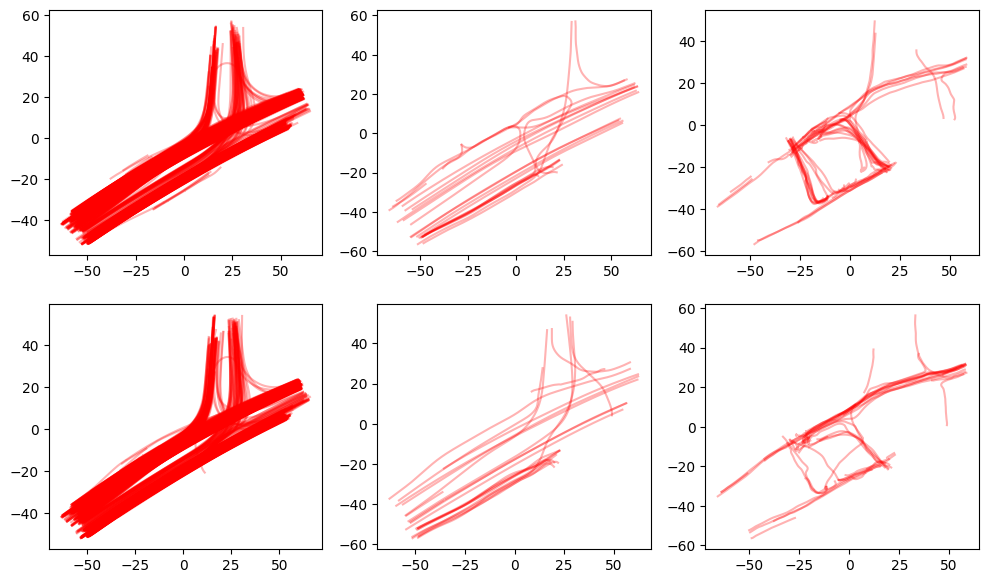

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

agent_type_list = [['car', 'truck_bus'], ['bicycle'], ['pedestrian']]
disambiguition = [
    [track_set[track_set["class"].isin(agent_types)] for agent_types in agent_type_list]
    for track_set in [validation_set, test_set] 
]

for i, tracksets in enumerate(disambiguition):
    for j, trackset in enumerate(tracksets):
        ids = trackset["trackId"].unique()
        for ref_group in group:
            group_tracks = trackset[trackset["group"] == ref_group]
            for trackId in ids:
                track = group_tracks[group_tracks["trackId"] == trackId]
                axes[i][j].plot(track["xCenter"], track["yCenter"], alpha = 0.3, color = "red")

## Experiments

In [49]:
    
def experiment1(
    vehicle_df: pd.DataFrame,
    width, height,
    seed_value: int = 2024,
    constitutional_trust: float = 0.8,
    interpolator: Any | None = None,
    N: int = 2500,
    dt: float = 1/25,
    sensor_std_error = 1,
    process_noise = array([30, 20]),
):
    def create_initial_particles(N: int) -> ndarray:
        return np.stack(
            [
                uniform(loc=-width / 2, scale=width).rvs(N),  # x position (east)
                uniform(loc=-height / 2, scale=height).rvs(N),  # y position (north)
                uniform(loc=0, scale=2 * pi).rvs(N),  # heading
                norm(loc=40, scale=10).rvs(N),  # speed
            ]
        ).T
    
    def predict(particles, dt, process_noise):
        """move according to control input u (heading change, velocity)
        with noise Q (std heading change, std velocity)`"""

        scaled_noise = process_noise * dt
        
        particles = particles.copy()
        N = len(particles)

        # We first add noise to the heading
        particles[:, 2] += deg2rad(
            scaled_noise[0] * standard_normal(N)  # we can turn 90 degrees per second in each direction (95% interval) # but this is per time step? = 1/25th sec
        )
        particles[:, 2] %= 2 * pi

        # Add noise to the speed
        particles[:, 3] += scaled_noise[1]  * standard_normal(N) # pm 40 kmh 

        # Compute the actual distance we travel
        distance = particles[:, 3] * dt / 3.6 # to scale to m/s
        particles[:, 0] += np.cos(particles[:, 2]) * distance
        particles[:, 1] += np.sin(particles[:, 2]) * distance

        return particles
    

    def update(
        particles,
        weights,
        z,
        R,
        dt,
        constitutional_trust: float = constitutional_trust,
    ):
        weights = weights.copy()

        positions = particles[:, :2]
        distance = np.linalg.norm(positions - z, axis=1)

        # Evaluate an RBF kernel
        if dt > 0.01:
            weights *= norm.pdf(distance, 0, R) # remove dt

        if constitutional_trust > 0:
            this_interpolator = interpolator
            constitution = this_interpolator(particles)[:, 0]
            weight_change = constitutional_trust * constitution + (1 - constitutional_trust)
            # Disallow going to placed where the constitution is not even defined
            weight_change[~np.isfinite(constitution)] = 0
            weights *= weight_change

        weights += 1.0e-300  # avoid round-off to zero
        weights /= sum(weights)  # normalize

        return weights
    

    def estimate(particles, weights):
        """returns mean and variance of the weighted particles"""

        mean = np.average(particles, weights=weights, axis=0)
        var = np.average((particles - mean) ** 2, weights=weights, axis=0)
        return mean, var

    def neff(weights):
        return 1.0 / np.sum(np.square(weights))

    def resample_from_index(particles, weights, indexes):
        particles[:] = particles[indexes]
        weights.resize(len(particles))
        weights.fill(1.0 / len(weights))

    def run_pf1(
        N: int,
        data: np.ndarray,
        sensor_std_err,
        process_noise,
        do_plot=False,
        plot_particles=True,
        plot_every=3,
        dt=dt,
    ):
        if do_plot:
            plt.figure()

        # Create particles uniformly over the entire space
        particles = create_initial_particles(N)

        # However, for the location we can do a bit better by assuming that the current
        # observation is approximately correct
        particles[:, 0] = norm(loc=data[0, 0], scale=10).rvs(N)
        particles[:, 1] = norm(loc=data[0, 1], scale=10).rvs(N)

        # create weights
        weights = np.ones(N) / N

        if do_plot and plot_particles:
            alpha = 0.20
            if N > 5000:
                alpha *= np.sqrt(5000) / np.sqrt(N)
            plt.scatter(particles[:, 0], particles[:, 1], alpha=alpha, color="g")
            plt.show()

        weights_trace = []
        particle_trace = []
        xs = []
        for i, obs in enumerate(data):
            dt = obs[4]
            # move
            particles = predict(particles, dt=dt, process_noise=process_noise)

            # incorporate measurements
            weights = update(particles, weights, z=obs[:2], R=sensor_std_err, dt=dt)

            # resample if too few effective particles
            if neff(weights) < N / 2:
                # print("resample")
                indexes = stratified_resample(weights)
                resample_from_index(particles, weights, indexes)
                assert np.allclose(weights, 1 / N)
            else:
                # print("don't resample")
                pass

            mu, var = estimate(particles, weights)
            xs.append(mu)

            weights_trace.append(weights.copy())
            particle_trace.append(particles.copy())

            if do_plot and i % plot_every == 0:
                if plot_particles:
                    # top 10 percent of weights
                    percentile = 80
                    top_10_weight_val = np.percentile(weights, percentile)
                    print(top_10_weight_val, weights.max())
                    boosted_heaviest = np.where(weights >= top_10_weight_val, weights, 0)

                    plt.scatter(particles[:, 0], particles[:, 1], alpha= 1 * boosted_heaviest, color="g")
                # draw a cricle perimeter at 1 std
                plt.gca().add_artist(
                    plt.Circle((mu[0], mu[1]), radius=sensor_std_err, fill=False)
                )
                p1 = plt.scatter(obs[0], obs[1], marker="x", color="r")
                p2 = plt.scatter(mu[0], mu[1], marker="s", color="b")
                plt.xlim(-width / 2, width / 2)
                plt.ylim(-height / 2, height / 2)
                plt.show()

        xs = np.array(xs)
        if do_plot:
            plt.legend([p1, p2], ["Actual", "PF"], loc=4, numpoints=1)
            plt.show()

        pos_error = np.linalg.norm(xs[:, :2] - data[:, :2], axis=1)
        all_error = np.linalg.norm(xs[:, :] - data[:, :4], axis=1)

        if do_plot:
            plt.show()

        return {
            "particles": array(particle_trace),
            "weights": array(weights_trace),
            "estimates": xs,
            "pos_error": pos_error,
            "pos_error_mean": pos_error.mean(),
            "all_error": all_error,
            "all_error_mean": all_error.mean(),
            "truth": data,
        }


    ground_truth = stack(
        (
            vehicle_df["xCenter"],
            vehicle_df["yCenter"],
            deg2rad(vehicle_df["heading"]),
            vehicle_df["speed"],
            np.repeat(dt, len(vehicle_df))
        )
    ).T

    seed(seed_value)
    return run_pf1(
        N=N,
        data=ground_truth,
        sensor_std_err=sensor_std_error,
        process_noise=process_noise,
        do_plot=False,
        plot_every=6,
        dt=dt,
    )

dt = 1 / 25
take_every = 25
df = validation_set[validation_set["group"] == group[0]]
trackId = df["trackId"].unique()[11]

compare = [experiment1(
    df[df["trackId"] == trackId][::take_every],
    width = dimensions_per_index[env_index][0],
    height = dimensions_per_index[env_index][1],
    seed_value=2025,
    constitutional_trust=trust_ratio,
    interpolator=support.get_interpolator(),
    dt=dt * take_every,
    process_noise=array([20, 30]),
    sensor_std_error=1,
    N=2500
) for trust_ratio in [0, 0.5, 1]]


res_specific = compare[1]


[0.16001981 0.07832976 0.13667551 0.09664677 0.06817215 0.10689837
 0.08217876 0.15768462 0.14966158]
[0.13437416 0.1126292  0.060474   0.05419823 0.13156371 0.13360559
 0.0682888  0.10626135 0.20176277]
[0.85498688 0.58116236 0.52707412 0.11954034 0.38322779 0.71560242
 0.69877915 0.70937447 0.26526284]


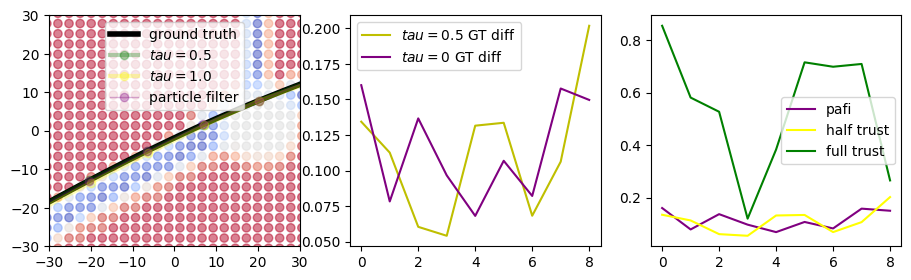

In [50]:
fig, axes = plt.subplots(1,3, figsize=(11,3))
axes[0].set_xlim(-30, 30)
axes[0].set_ylim(-30, 30)

plot = support.scatter(bearing = 270, speed = 40, plot_basemap=False, alpha=0.5, cmap = "coolwarm_r", ax = axes[0])
track = df[df["trackId"] == trackId]
axes[0].plot(track["xCenter"][20:], track["yCenter"][20:], linewidth=4, color="black", label="ground truth")

estimates1 = compare[1]["estimates"]
axes[0].plot(estimates1[:, 0], estimates1[:, 1], "o-", linewidth=3, alpha=0.3, color="green", label="$tau=0.5$")
estimates2 = compare[2]["estimates"]
axes[0].plot(estimates2[:, 0], estimates2[:, 1], "o-", linewidth=3, alpha=0.3, color="yellow", label="$tau=1.0$")
pafi = compare[0]["estimates"]
axes[0].plot(pafi[:, 0], pafi[:, 1], "o-", linewidth=1, alpha=0.3, color="purple", label="particle filter")

x = np.arange(len(pafi))
gt = df[df["trackId"] == trackId][::take_every][["xCenter", "yCenter"]]

d1 = np.linalg.norm(gt - estimates1[:, :2], axis=1)
d2 = np.linalg.norm(gt - pafi[:, :2], axis=1)
axes[1].plot(x, d1, c="y", label="$tau=0.5$ GT diff")
axes[1].plot(x, d2, c="purple", label="$tau=0$ GT diff")

for i, (label, color) in enumerate(zip(["pafi", "half trust", "full trust"], ["purple", "yellow", "green"])):
    data = compare[i]["pos_error"]
    print(data)
    axes[2].plot(x, data, c=color, label=label)  

axes[0].legend()
axes[1].legend()
axes[2].legend()
pass

In [51]:
estimates = res_specific["estimates"][:, :2]
truth = res_specific["truth"]
len(estimates), len(truth)
for i in range(3):
    print (compare[i]["pos_error_mean"])


0.11514081525032961
0.11146198091485236
0.5394455964429956


### Experiment
Now that a single example runs through, it is time to evaluate the performance of a particle filter both with our constitution and without it. What split to use?



Text(0.5, 0, 'number of agents')

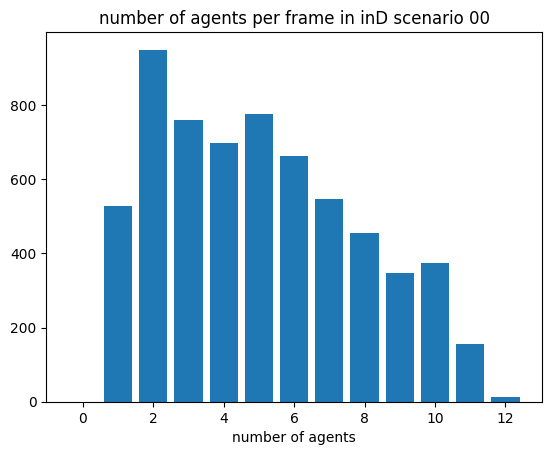

In [52]:
by_frames = validation_set[validation_set["group"] == inD_index].groupby("frame").count()
max_agents = by_frames["trackId"].max() + 1
agents_per_frame = [len(by_frames[by_frames["trackId"] == i]) for i in range(max_agents)]
ax = plt.subplot()
ax.bar(np.arange(max_agents), agents_per_frame)
ax.set_title(f"number of agents per frame in inD scenario {inD_index}")
ax.set_xlabel("number of agents")

In [53]:
from operator import itemgetter

In [54]:
def evaluate_trust_ratio(data: pd.DataFrame, N: int, sample_every: int, group, env_index, interpolator):
    trust_partitions = 10

    group_parts = [data[data["group"] == group_index] for group_index in group]
    
    return np.concatenate([
        stack([
            np.array(
                [itemgetter("pos_error_mean", "all_error_mean")(experiment1(
                    part[part["trackId"] == trackId][::sample_every],
                    width = dimensions_per_index[env_index][0],
                    height = dimensions_per_index[env_index][1],
                    seed_value=2026,
                    constitutional_trust=trust,
                    interpolator=interpolator,
                    N=N,
                    dt=sample_every*dt,
                    process_noise=array([20, 30])
                )) for trust in np.arange(trust_partitions + 1) / trust_partitions]
            ) for trackId in part["trackId"].unique()[::3]]
        )
    for part in group_parts], axis=0)

In [55]:
Ns = [2000, 5000] # [100, 250, 500, 1000, 1500]
for_n = []

car_data = disambiguition[0][0]

for n in Ns:
    for_n.append(evaluate_trust_ratio(car_data, N=n, sample_every=25))

TypeError: evaluate_trust_ratio() missing 3 required positional arguments: 'group', 'env_index', and 'interpolator'

In [ ]:
from itertools import product
from tqdm import tqdm

In [ ]:
process_noise_v = np.arange(10, 101, 10)
process_noise_b = np.arange(10, 101, 10)
ns = [2000] # np.array([1000, 2000, 4000])
sampling_rates = [18] #np.array([12, 18, 25, 37])

grid_search_results = []


interpolator = support.get_interpolator()
data = validation_set
group_parts = [data[data["group"] == group_index] for group_index in group]
trust = 0.5
sensor_std_error = 1

for v, b, n, sample_rate in tqdm(product(process_noise_v, process_noise_v, ns, sampling_rates)):
    grid_search_results.append(
        [v, b, n, sample_rate, sensor_std_error, trust, *np.mean(    
            np.concatenate([
                np.array(
                    [itemgetter("pos_error_mean", "all_error_mean")(experiment1(
                        part[part["trackId"] == trackId][::sample_rate],
                        width = dimensions_per_index[env_index][0],
                        height = dimensions_per_index[env_index][1],
                        seed_value=2026,
                        constitutional_trust=trust,
                        interpolator=interpolator,
                        N=n,
                        process_noise=array([v, b]),
                        sensor_std_error = sensor_std_error,
                        dt=sample_rate*dt
                )) for trackId in part["trackId"].unique()[::10]])
            for part in group_parts], axis=0),
        axis=0)
    ])

grid_search_results = pd.DataFrame(array(grid_search_results), 
    columns=["v_noise", "b_noise", "n", "rate", "std_err", "trust", "pos_error_mean", "all_error_mean"])
grid_search_results.to_csv(output_folder / f"gridsearch_res_{inD_index}.csv")


In [ ]:
grid_search_results[grid_search_results["pos_error_mean"] < 0.16] # == grid_search_results["pos_error_mean"].min()]

In [ ]:
grid_search_results["pos_error_mean"].mean()

In [56]:
def plot_ratios(n, data, env_index, logic_name):

    # print(f"N = {n}")
    # print(np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5))
    # print(data[:, :, 0].mean(axis = 0))
    
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(
        np.arange(data.shape[1]) / (data.shape[1]-1), 
        np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)[0], 
        width=0.1,
        tick_label = np.arange(data.shape[1]) / (data.shape[1]-1),
    )
    ax.set_title(f"Optimal Trust Level for Different N on Intersection {env_index}")

    plt.savefig(output_folder / "figures" / f"optimal_trust_hist-{env_index}--{logic_name}.svg", format="svg")
    
    fig, ax = plt.subplots(figsize=(6, 4))
    index_min = pd.DataFrame({
        "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
        "relative error": data[:, :, 0].min(axis=1) / data[:, 0, 0],
    })    
    sns.lineplot(data=index_min, x="index", y="relative error", ax=ax)
    ax.set_title(f"Mean Improvement for Optimal Trust Level on Intersection {env_index}")
    ax.set_xlabel("optimal $tau$")

    plt.savefig(output_folder / "figures" / f"optimal_trust_error_rel-{env_index}--{logic_name}.svg", format="svg")

    # fig, ax = plt.subplots(figsize=(6, 4))
    # index_min = pd.DataFrame({
    #     "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
    #     "absolute error": data[:, :, 0].min(axis=1),
    # })    
    # sns.lineplot(data=index_min, x="index", y="absolute error", ax=ax)
    # ax.set_title(f"Mean Improvement for Optimal Trust Level on Intersection {env_index}")
    # ax.set_xlabel("optimal $tau$")
    # ax.legend()

    # plt.savefig(output_folder / "figures" / f"optimal_trust_error_abs-{env_index}--{logic_name}.svg", format="svg")


In [ ]:
plot_ratios(Ns, for_n, env_index, logic_name)

NameError: name 'logic_name' is not defined

In [58]:
logic_name = "sides_full"
for env_index, group in [("00", group00), ("07", group07), ("18", group18), ("30", group30)]:
    v_set, t_set = val_test_split(group)

    n = 3000
    car_data = v_set[v_set["class"].isin(["car", "truck_bus"])]
    support = CartesianDeltaCollection.load(promis_path / f"landscape-{env_index}--{logic_name}.pkl")

    for_n = evaluate_trust_ratio(car_data, n, 25, group, env_index, support.get_interpolator())
    
    plot_ratios(n, for_n, env_index, logic_name)

KeyboardInterrupt: 

In [ ]:
data = car_data
group_parts = [data[data["group"] == group_index] for group_index in group]
sum([len(part["trackId"].unique()) for part in group_parts])

In [ ]:
def analyze_divergence(data: pd.DataFrame, group: list[str], env_index: str, N: int, sample_every: int, support: str):
    ax = plt.subplot()
    interpolator = support.get_interpolator()
    support.scatter(bearing = 320, speed = 30, ax=ax, alpha=0.5, cmap="coolwarm_r")
    trust = 0.8
    w, h = dimensions_per_index[env_index]

    for g_id in group:
        car_data = data[data["group"] == g_id]
        for trackId in car_data["trackId"].unique():
            res = experiment1(
                car_data[car_data["trackId"] == trackId][::sample_every],
                seed_value=2026,
                constitutional_trust=trust,
                interpolator=interpolator,
                N=N,
                dt=sample_every*dt,
                width=w, 
                height=h,
            )
            error = res["pos_error"]
            pred = res["estimates"]
            pos = car_data[car_data["trackId"] == trackId][::sample_every][["xCenter", "yCenter"]].to_numpy()
            hi_error = np.quantile(error, 0.95)
            hi_error_pos = pos[error >= hi_error, :]
            hi_error_pred = pred[error >= hi_error, :]
            ax.scatter(hi_error_pred[:, 0], hi_error_pred[:, 1], alpha=0.9, c="red", s=4)
            for i in range(len(hi_error_pos)):
                ax.plot(
                    [hi_error_pos[i, 0], hi_error_pred[i, 0]],
                    [hi_error_pos[i, 1], hi_error_pred[i, 1]],
                    c="black",
                )

    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)
    return ax


In [59]:
support = CartesianCollection.load(promis_path / "landscape-30--sides_full.pkl")
analyze_divergence(val_test_split(group30)[0], group30, "30", 3000, 25, support)
group30

NameError: name 'analyze_divergence' is not defined

In [60]:
from promis.geo import BufferedCartesianPolygon, CartesianPolyLine

In [98]:
# now, we want to better the predictions for agents exiting the road from the upper left
# there is a stop sign, which we model as a line agents might cross:
def refine30():
    uam = CartesianMap.load(uam_path / "uam-30.pkl")

    # coordinates taken from OSM
    stop_sign_loc = PolarLocation(6.1654369, 50.7789007).to_cartesian(uam.origin)

    uam.features.append(
        #BufferedCartesianPolygon.buffer_polyline(
            CartesianPolyLine(
                [ #CartesianLocation(x, y) for x, y in [
                    stop_sign_loc,
                    stop_sign_loc.__add__(array([[-5],[ 5]]))
                ], # ],
                location_type="stop_sign",
                covariance= 4 * np.eye(2),
                origin=uam.origin,
            )
        #)
    )

    logic = """obeys_halts(X) :-
        crosses(X, stop_sign),
        slow_down(X);
        not crosses(X, stop_sign).

obeys_speed_limit(X) :-
    state_speed(X, S),
    S =< 50.

slow_down(X) :-  
    state_speed(X, S),
    S =< 20.

landscape(X) :- 
    obeys_halts(X),
    obeys_speed_limit(X)."""

    star = DeltaStaRMap(uam, dt = 0.5)
    support = DeltaGrid(uam.origin, (30, 30), 80, 80, 2, speed_bounds=(15, 55))
    star.initialize(support, 15, logic)

    ProMis(star).solve(support, logic, show_progress=True)
    return support


In [99]:
landscape_refined_30 = refine30()

[[-40.         -40.           0.          15.        ]
 [-37.24137931 -40.           0.          15.        ]
 [-34.48275862 -40.           0.          15.        ]
 ...
 [ 34.48275862  40.         360.          55.        ]
 [ 37.24137931  40.         360.          55.        ]
 [ 40.          40.         360.          55.        ]]
        east  north  bearing  speed   v0   v1
0 -40.000000  -40.0      0.0   15.0  0.0  0.0
1 -37.241379  -40.0      0.0   15.0  0.0  0.0
2 -34.482759  -40.0      0.0   15.0  0.0  0.0
3 -31.724138  -40.0      0.0   15.0  0.0  0.0
4 -28.965517  -40.0      0.0   15.0  0.0  0.0


/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/promis.py:204: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"state_{evaluation_points.data.columns[i]}(x_{index}, {state[i]})."


Output()

In [100]:
landscape_refined_30.save(promis_path / "brake_20_osm_flat_dt05.pkl")


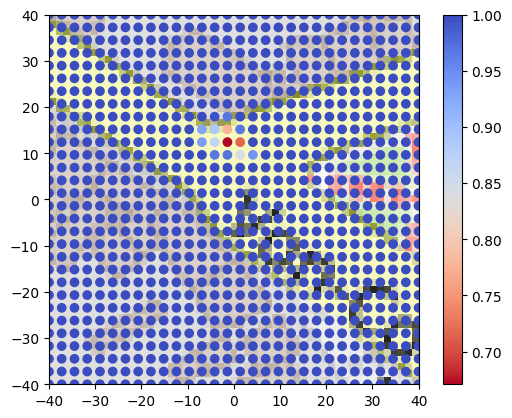

In [101]:
img = landscape_refined_30.scatter(bearing=225, speed=20, cmap="coolwarm_r")
plt.colorbar(img)

In [70]:
v_set, t_set = val_test_split(group30)
n = 3000
car_data = v_set[v_set["class"].isin(["car", "truck_bus"])]
for_n = evaluate_trust_ratio(car_data, n, 13, group30, "30", landscape_refined_30.get_interpolator())
print(for_n.mean(axis = 0))
# plot_ratios(n, for_n, env_index, "brakes30")

[[0.15617068 2.37633614]
 [0.17846839 2.36822852]
 [0.19880211 3.01677015]
 [0.22838957 3.42336734]
 [0.26944111 3.11269704]
 [0.29406063 6.99389302]
 [0.34672491 3.57190316]
 [0.37413332 3.9038831 ]
 [0.40049563 4.29956715]
 [0.41414789 4.69343709]
 [0.42734191 4.8060977 ]]


In [ ]:
refined_i = landscape_refined_30.get_interpolator()
sides_i = CartesianDeltaCollection.load(promis_path / "landscape-30--sides.pkl").get_interpolator()
interpolator = lambda x: refined_i(x) * sides_i(x)
for_n = evaluate_trust_ratio(car_data, n, 25, group30, "30", interpolator)
print(for_n.mean(axis=0))
# plot_ratios(n, for_n, env_index, "brakes30+sides")

In [92]:
def error_data_for_logics(group, env_index, interpolators, n = 3000):
    v_set, t_set = val_test_split(group)
    car_data = v_set
    data_list = {}
    for logic_name, interpolator in interpolators.items():
        data = evaluate_trust_ratio(car_data, n, 12, group, env_index, interpolator)
        data_list[logic_name] = data

    return data_list

In [102]:
refined_i = landscape_refined_30.get_interpolator()
sides_half_i = CartesianDeltaCollection.load(promis_path / "landscape-30--sides.pkl").get_interpolator()
sides_i = CartesianDeltaCollection.load(promis_path / "landscape-30--sides_full.pkl").get_interpolator()
error_data = error_data_for_logics(group30, "30", {
    "lanes": sides_i,
    # "lanes,\nhalf intersection": sides_half_i,
    "stop sign": refined_i,
    "lanes,\nstop sign": lambda x: refined_i(x) * sides_i(x)
    },
    n=3000   
)

In [ ]:
def compare_opt_trust(env_index, data_list: dict):
    fig, ax = plt.subplots(figsize=(6,4))
    width = 0.2
    trust_num = 11
    x = np.arange(trust_num)
    for i, (logic_name, data) in enumerate(data_list.items()):
        offset = i * width
        x_ = x + offset
        ax.bar(
            x_, 
            np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)[0], 
            width=width,
            label=logic_name,   
        )

    ax.set_title(f"Optimal Trust Level on Intersection {env_index} for Different Logics")
    ax.set_xticks(x+width, x / (trust_num - 1))
    ax.legend(loc='upper right')
    plt.savefig(output_folder / "figures" / f"tau_comp_hist-{env_index}.svg", format="svg")
        

    fig, ax = plt.subplots(figsize=(6, 4))
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
            "relative error": data[:, :, 0].min(axis=1) / data[:, 0, 0],
            },
        )    
        sns.lineplot(data=index_min, x="index", y="relative error", ax=ax, label=logic_name,)

    ax.set_title(f"Mean Improvement for Optimal Trust Level on Intersection {env_index}")
    ax.set_xlabel("optimal $tau$")
    ax.set_ylabel("mean relative error")
    ax.legend(loc='upper right')

    plt.savefig(output_folder / "figures" / f"tau_rel_error_comp-{env_index}.svg", format="svg")

    fig, ax = plt.subplots(figsize=(6, 4))
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
            "absolute error": data[:, :, 0].min(axis=1),
            },
        )    
        sns.lineplot(data=index_min, x="index", y="absolute error", ax=ax, label=logic_name,)
        
    ax.set_title(f"Mean Error for Optimal Trust Level on Intersection {env_index}")
    ax.set_xlabel("optimal $tau$")
    ax.set_ylabel("mean error")
    ax.legend(loc='upper right')
    plt.savefig(output_folder / "figures" / f"tau_abs_error_comp-{env_index}.svg", format="svg")

    fig, ax = plt.subplots(figsize=(6, 4))

    for i, (logic_name, data) in enumerate(data_list.items()):
        ax.violinplot(data[:, :, 0].min(axis=1), [2*(i + 1)],
            showmeans=True, showextrema=True,
        )
        ax.text(2*(i+1), 0.05, str(data[:, :, 0].min(axis=1).mean())[:5]    )

    # for a particle filter, predictions should be the same for all logics
    ax.violinplot(data[:, 0, 0], [0],
        showmeans=True, showextrema=True,
    )
    ax.text(0, 0.05, str(data[:, 0, 0].mean())[:5])
        
    ax.set_title(f"Mean Error for Best Prediction on Intersection {env_index}")
    ax.set_xlabel("logic")
    ax.set_xticks([2*i for i in range(len(data_list) + 1)], ["particle filter", *data_list.keys()])

    ax.set_ylabel("mean error")
    ax.legend(loc='upper right')
    plt.savefig(output_folder / "figures" / f"tau_mean_error_comp-{env_index}.svg", format="svg")



/tmp/ipykernel_752706/2173588497.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


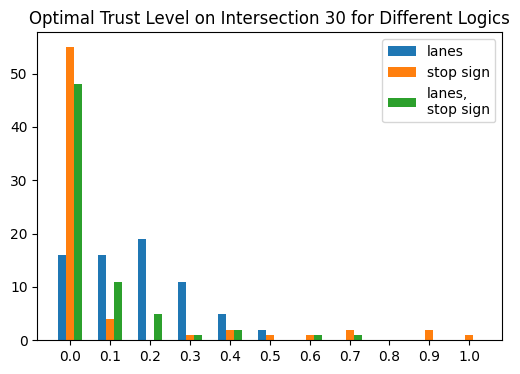

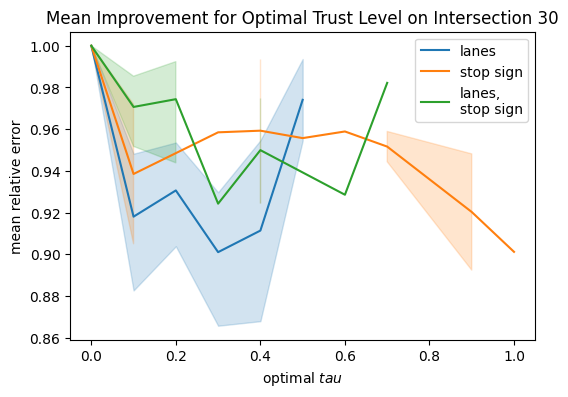

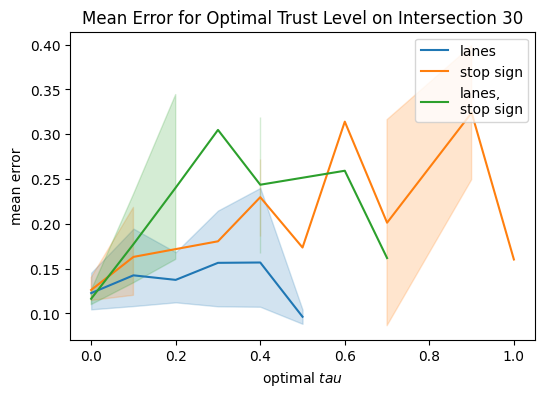

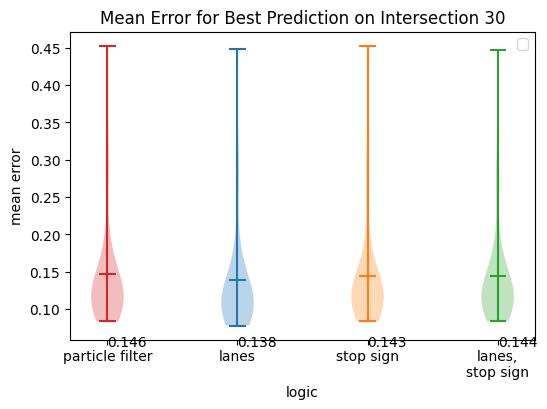

In [104]:
compare_opt_trust("30", error_data)

In [ ]:
l1 = CartesianDeltaCollection.load(promis_path / "landscape-30--sides_full.pkl")
l2 = CartesianDeltaCollection.load(promis_path / "brake_30.pkl")
l1.data["v0"] = l1.data["v0"] * l2.data["v0"]
l1.save(promis_path / "landscape-30--sides_full+brake_30.pkl")

In [ ]:
# analyze_divergence(v_set, group30, "30", 3000, 25, l1)
l1.scatter(bearing=225, speed=20, cmap="coolwarm_r")

### Dynamic interactions
We now want to calculatre a dynamic interaction map centered on points around our car. For that, we do not calcuate a map holding road information.
The resolution needs not to be high

In [ ]:
landscape = CartesianCollection.load(promis_path / "landscape-00--sides.pkl")
print(validation_set.columns)
scene = validation_set[(validation_set["group"] == "00") & (validation_set["frame"] == 90)]
landscape.scatter(bearing=180, speed=0, cmap="coolwarm_r", alpha=0.5)
plt.scatter(scene["xCenter"], scene["yCenter"], c="g")

In [ ]:
"""
i_drive :-
    near_crossing,
    right_of_way,
    not pedestrian(front).

right_of_way :-
    not car(right),
    not truck_bus(right);
"""

In [ ]:
class CartesianDeltaLocation(CartesianLocation):
    def __init__(self, east, north, bearing = 0., speed = 0., location_type = None, name = None, identifier = None, covariance = None, origin = None):
        super().__init__(east, north, location_type, name, identifier, covariance, origin)
        self.bearing = bearing
        self.speed = speed

# Vorfahrtsstraße
# Rechts vor Links
# Zentrale Frage: wer hat Vorfahrt?

interaction_logic_car = """



"""

def calculate_interaction_map(logic, ego_agent, scene, dt):
    scene = scene[["xCenter", "yCenter", "bearing", "speed", "class"]]

    # we look into the future and thus it would be a fallacy to use the map as is
    # we therefore rely on our naive state estimations, but with high uncertainty
    AGENT_COV = 2
    scene["xCenter"]

    interaction_uam = CartesianMap(uam.origin, features=
        uam.features 
        + [CartesianDeltaLocation(*row, covariance=AGENT_COV) for row in scene]
        + [CartesianDeltaLocation(*ego_agent, location_type=)]
    )
    width, height = dimensions_per_index[group[0]]
    support = DeltaGrid(uam.origin, (15, 15), width, height, speed_res=1, bearing_res=7)
    interaction_star = DeltaStaRMap(interaction_uam)
    interaction_star.initialize(support, 10, logic)
    ProMis(interaction_star).solve(support)
    return support

    


In [ ]:
    
def experiment2(
    vehicle_df: pd.DataFrame,
    width, height,
    seed_value: int = 2024,
    constitutional_trust: float = 0.8,
    interpolator: Any | None = None,
    N: int = 2500,
    dt: float = 1/25,
    sensor_std_error = 1,
    process_noise = array([30, 20]),
):
    def create_initial_particles(N: int) -> ndarray:
        return np.stack(
            [
                uniform(loc=-width / 2, scale=width).rvs(N),  # x position (east)
                uniform(loc=-height / 2, scale=height).rvs(N),  # y position (north)
                uniform(loc=0, scale=2 * pi).rvs(N),  # heading
                norm(loc=40, scale=10).rvs(N),  # speed
            ]
        ).T
    
    def predict(particles, dt, process_noise):
        """move according to control input u (heading change, velocity)
        with noise Q (std heading change, std velocity)`"""

        scaled_noise = process_noise * dt
        
        particles = particles.copy()
        N = len(particles)

        # We first add noise to the heading
        particles[:, 2] += deg2rad(
            scaled_noise[0] * standard_normal(N)  # we can turn 90 degrees per second in each direction (95% interval) # but this is per time step? = 1/25th sec
        )
        particles[:, 2] %= 2 * pi

        # Add noise to the speed
        particles[:, 3] += scaled_noise[1]  * standard_normal(N) # pm 40 kmh 

        # Compute the actual distance we travel
        distance = particles[:, 3] * dt / 3.6 # to scale to m/s
        particles[:, 0] += np.cos(particles[:, 2]) * distance
        particles[:, 1] += np.sin(particles[:, 2]) * distance

        return particles
    

    def update(
        particles,
        weights,
        z,
        R,
        dt,
        constitutional_trust: float = constitutional_trust,
    ):
        weights = weights.copy()

        positions = particles[:, :2]
        distance = np.linalg.norm(positions - z, axis=1)

        # Evaluate an RBF kernel
        if dt > 0.01:
            weights *= norm.pdf(distance, 0, R) # remove dt

        if constitutional_trust > 0:
            this_interpolator = interpolator
            constitution = this_interpolator(particles)[:, 0]
            weight_change = constitutional_trust * constitution + (1 - constitutional_trust)
            # Disallow going to placed where the constitution is not even defined
            weight_change[~np.isfinite(constitution)] = 0
            weights *= weight_change

        weights += 1.0e-300  # avoid round-off to zero
        weights /= sum(weights)  # normalize

        return weights
    

    def estimate(particles, weights):
        """returns mean and variance of the weighted particles"""

        mean = np.average(particles, weights=weights, axis=0)
        var = np.average((particles - mean) ** 2, weights=weights, axis=0)
        return mean, var

    def neff(weights):
        return 1.0 / np.sum(np.square(weights))

    def resample_from_index(particles, weights, indexes):
        particles[:] = particles[indexes]
        weights.resize(len(particles))
        weights.fill(1.0 / len(weights))

    def run_pf1(
        N: int,
        data: np.ndarray,
        sensor_std_err,
        process_noise,
        do_plot=False,
        plot_particles=True,
        plot_every=3,
        dt=dt,
    ):
        if do_plot:
            plt.figure()

        # Create particles uniformly over the entire space
        particles = create_initial_particles(N)

        # However, for the location we can do a bit better by assuming that the current
        # observation is approximately correct
        particles[:, 0] = norm(loc=data[0, 0], scale=10).rvs(N)
        particles[:, 1] = norm(loc=data[0, 1], scale=10).rvs(N)

        # create weights
        weights = np.ones(N) / N

        if do_plot and plot_particles:
            alpha = 0.20
            if N > 5000:
                alpha *= np.sqrt(5000) / np.sqrt(N)
            plt.scatter(particles[:, 0], particles[:, 1], alpha=alpha, color="g")
            plt.show()

        weights_trace = []
        particle_trace = []
        xs = []
        for i, obs in enumerate(data):
            dt = obs[4]
            # move
            particles = predict(particles, dt=dt, process_noise=process_noise)

            # incorporate measurements
            weights = update(particles, weights, z=obs[:2], R=sensor_std_err, dt=dt)

            # resample if too few effective particles
            if neff(weights) < N / 2:
                # print("resample")
                indexes = stratified_resample(weights)
                resample_from_index(particles, weights, indexes)
                assert np.allclose(weights, 1 / N)
            else:
                # print("don't resample")
                pass

            mu, var = estimate(particles, weights)
            xs.append(mu)

            weights_trace.append(weights.copy())
            particle_trace.append(particles.copy())

            if do_plot and i % plot_every == 0:
                if plot_particles:
                    # top 10 percent of weights
                    percentile = 80
                    top_10_weight_val = np.percentile(weights, percentile)
                    print(top_10_weight_val, weights.max())
                    boosted_heaviest = np.where(weights >= top_10_weight_val, weights, 0)

                    plt.scatter(particles[:, 0], particles[:, 1], alpha= 1 * boosted_heaviest, color="g")
                # draw a cricle perimeter at 1 std
                plt.gca().add_artist(
                    plt.Circle((mu[0], mu[1]), radius=sensor_std_err, fill=False)
                )
                p1 = plt.scatter(obs[0], obs[1], marker="x", color="r")
                p2 = plt.scatter(mu[0], mu[1], marker="s", color="b")
                plt.xlim(-width / 2, width / 2)
                plt.ylim(-height / 2, height / 2)
                plt.show()

        xs = np.array(xs)
        if do_plot:
            plt.legend([p1, p2], ["Actual", "PF"], loc=4, numpoints=1)
            plt.show()

        pos_error = np.linalg.norm(xs[:, :2] - data[:, :2], axis=1)
        all_error = np.linalg.norm(xs[:, :] - data[:, :4], axis=1)

        if do_plot:
            plt.show()

        return {
            "particles": array(particle_trace),
            "weights": array(weights_trace),
            "estimates": xs,
            "pos_error": pos_error,
            "pos_error_mean": pos_error.mean(),
            "all_error": all_error,
            "all_error_mean": all_error.mean(),
            "truth": data,
        }


    ground_truth = stack(
        (
            vehicle_df["xCenter"],
            vehicle_df["yCenter"],
            deg2rad(vehicle_df["heading"]),
            vehicle_df["speed"],
            np.repeat(dt, len(vehicle_df))
        )
    ).T

    seed(seed_value)
    return run_pf1(
        N=N,
        data=ground_truth,
        sensor_std_err=sensor_std_error,
        process_noise=process_noise,
        do_plot=False,
        plot_every=6,
        dt=dt,
    )

dt = 1 / 25
trackId = 12
take_every = 25
df = validation_set[validation_set["group"] == group[0]]

compare = [experiment1(
    df[df["trackId"] == trackId][::take_every],
    width = dimensions_per_index[env_index][0],
    height = dimensions_per_index[env_index][1],
    seed_value=2025,
    constitutional_trust=trust_ratio,
    interpolator=support.get_interpolator(),
    dt=dt * take_every,
    process_noise=array([20, 30]),
    sensor_std_error=1,
    N=2500
) for trust_ratio in [0, 0.5, 1]]

res_specific = compare[1]
